# Informe Técnico de Análisis de Sentimiento: Dataset Yelp

---
## Enlace a este notebook:
https://colab.research.google.com/drive/1zwU3SsKhZH-SN2ZZkq4kC5tpUspZ3Pyr?usp=sharing

---

## 1. Motivación, Problema y Datos
- **Origen:** Dataset `yelp_review_full` con **650,000 reseñas**.
- **Link:** https://huggingface.co/datasets/Yelp/yelp_review_full
- **Importancia:** Automatizar la gestión de reputación para manejar volúmenes masivos de feedback.
- **Desafíos:** Ambigüedad lingüística y alta variabilidad en la extensión de los textos.

## 2. Justificación de la IA
- **Escalabilidad:** Procesamiento de medio millón de registros de forma casi instantánea.
- **Consistencia:** Clasificación objetiva sin la fatiga o sesgo de un revisor humano.

## 3. Variable Objetivo
- **Definición:** Variable Categórica `sentiment` (0: Negativo, 1: Positivo).
- **Estadísticas:** El dataset presenta un **60.0% de reseñas negativas (390,000 casos)** y un **40.0% de reseñas positivas (260,000 casos)**.

## 4. Análisis de Distribuciones (Estándares EDA)
- **Distribución de Clases:** Se utilizaron gráficos de barras para mostrar la frecuencia de cada categoría de sentimiento.
- **Métricas de Texto (Variable Numérica Asimétrica):** Debido a la presencia de valores atípicos y sesgo, se analizó el `word_count` mediante la mediana y el rango.
  - **Mediana:** 99.0 palabras.
  - **Rango Intercuartil (IQR):** 123.0 (Q1: 52.0, Q3: 175.0).
  - **Justificación:** Se optó por Boxplots y la mediana ya que la media se ve afectada por reseñas extremadamente largas (hasta 1,052 palabras).

## 5. Calidad de Datos y Patrones
- **Manejo de Datos:** No hay valores nulos. Los valores atípicos (reseñas muy largas) se mantienen para análisis, pero se identifican claramente en los diagramas de caja.
- **Insights:** Los usuarios que dejan reseñas negativas (1-3 estrellas) tienden a ser más descriptivos y extensos que aquellos que dejan reseñas positivas.

## 6. Conclusiones y Próximos Pasos
- **Hallazgos:** El dataset está desbalanceado (60/40), lo cual debe considerarse al elegir las métricas de evaluación del modelo (ej. F1-Score en lugar de Accuracy).


## Fase 1: Carga y Preparación de Datos
En esta sección importamos las librerías necesarias y cargamos el dataset completo de Yelp.

In [ ]:

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import re
import seaborn as sns

from nltk.corpus import stopwords
from collections import Counter


In [ ]:

splits = {'train': 'yelp_review_full/train-00000-of-00001.parquet', 'test': 'yelp_review_full/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/Yelp/yelp_review_full/" + splits["train"])


In [ ]:

df.head()


,label,text
0,4,dr. goldberg offers everything i look for in a...
1,1,"Unfortunately, the frustration of being Dr. Go..."
2,3,Been going to Dr. Goldberg for over 10 years. ...
3,3,Got a letter in the mail last week that said D...
4,0,I don't know what Dr. Goldberg was like before...


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   label   650000 non-null  int64 
 1   text    650000 non-null  object
dtypes: int64(1), object(1)
memory usage: 9.9+ MB


## Fase 2: Análisis Exploratorio de Datos (EDA)
### 2.1 Distribución de Ratings Originales
Visualizamos cómo se distribuyen las calificaciones de 1 a 5 estrellas para entender el balance inicial de los datos.

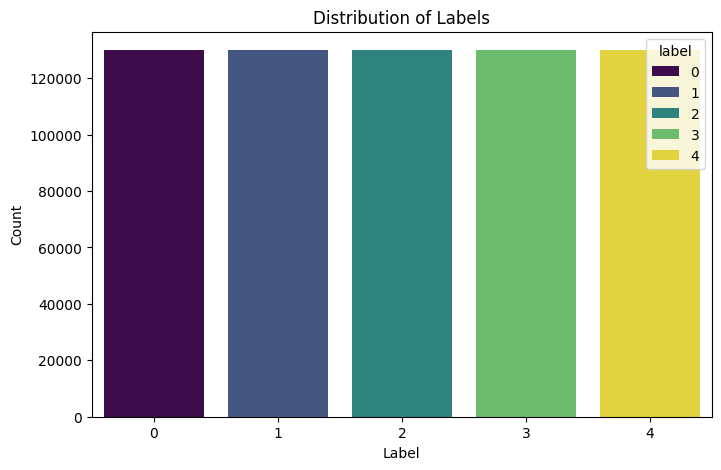

In [ ]:

# 1. Distribution of Labels
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, hue='label', palette='viridis')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


In [ ]:

# 2. Add text length columns for analysis
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("Summary Statistics for Text Length:")
display(df[['text_length', 'word_count']].describe())


Summary Statistics for Text Length:


,text_length,word_count
count,650000.000000,650000.000000
mean,732.325468,134.098089
std,663.721184,121.396115
min,1.000000,1.000000
25%,287.000000,52.000000
50%,539.000000,99.000000
75%,957.000000,175.000000
max,5637.000000,1052.000000


### 2.2 Análisis de Variables Numéricas Asimétricas
Calculamos la longitud del texto y el conteo de palabras para identificar patrones en la extensión de las reseñas y detectar valores atípicos (outliers).

In [ ]:
# Find the index of the review with the maximum text_length
longest_char_idx = df['text_length'].idxmax()
longest_word_idx = df['word_count'].idxmax()

print("-" * 60)
print(f"Review with most characters (Index {longest_char_idx}):")
print(f"Character count: {df.loc[longest_char_idx, 'text_length']}")
print(f"Word count: {df.loc[longest_char_idx, 'word_count']}")
print("-" * 60)
print(f"Review with most words (Index {longest_word_idx}):")
print(f"Character count: {df.loc[longest_word_idx, 'text_length']}")
print(f"Word count: {df.loc[longest_word_idx, 'word_count']}")
print("-" * 60)
# print(df.loc[longest_char_idx, 'text'][:500] + "...") # Showing first 500 chars

------------------------------------------------------------
Review with most characters (Index 614419):
Character count: 5637
Word count: 877
------------------------------------------------------------
Review with most words (Index 241540):
Character count: 4978
Word count: 1052
------------------------------------------------------------


In [ ]:
df.loc[longest_word_idx, 'text']

'I made my appointment for a yearly PAP & seen her for the first time. I waited almost an hour to be seen. I was asked if a student could watch, I was fine with that. I didn\'t think about it during visit but after I was worried thinking that Dr. did nothing but sit in the room while the student did my ENTIRE exam. Now I feel as if my test was probably not done right. I also had a red bump on my breast that had been there for a few weeks, I showed Dr. Brass. She thought it was ring worm, I knew it wasn\'t & she gave me a cream & told me to let her know if it didn\'t go away. While I was there I asked that they also test for STD\'s just to be safe, as I always do when getting a PAP. Come to find out she never made notes to test for that so it was never done at the lab. I wasn\'t going to make a big deal about it so I just never said anything. My second visit was due to finding out I had a fibroid/polyp in my uterus from my primary care doctor and was told to follow-up with my gnyo. I ca

In [ ]:
df.loc[longest_char_idx, 'text']

'Pour le jour de l\'an 2010, nous \\u00e9tions a Edinburgh, la neige \\u00e9tait au rendez-vous ainsi que le froid glacial.\\n\\n\\n Le sapin (voir photo) vient du grand magasin \\u00e0 5 ou 6 \\u00e9tage, Jenners (on y trouve de tout, je vous invite \\u00e0 gouter a leur restauration).\\n\\n\\n L\'\\u00e9cureuil, je l\'ai rencontre dans le jardin de \\"Princes Street Gardens\\" jour de l\'an.\\n\\n\\n Et pour les 12 coups de minuits, nous avons assist\\u00e9 au concert du groupe qui a donn\\u00e9 naissance au Ska, Madness. Dans le jardin sit\\u00e9 pr\\u00e9c\\u00e9demment. Je vais vous racont\\u00e9 notre incroyable chance au cours de la nuit de Hogmanay. Cette nuit l\\u00e0, \\u00e9tait le dernier jour de l\'ann\\u00e9e et en \\u00e9cossais cela s\'appelle Hogmanay.\\n\\n\\n Un petit aper\\u00e7u en vid\\u00e9o : http://vimeo.com/9888642 \\n\\n\\n Pour c\\u00e9l\\u00e9brer cette f\\u00eate, la ville d\'Edinburgh et plus particuli\\u00e8rement une partie de Princes Street ainsi que l

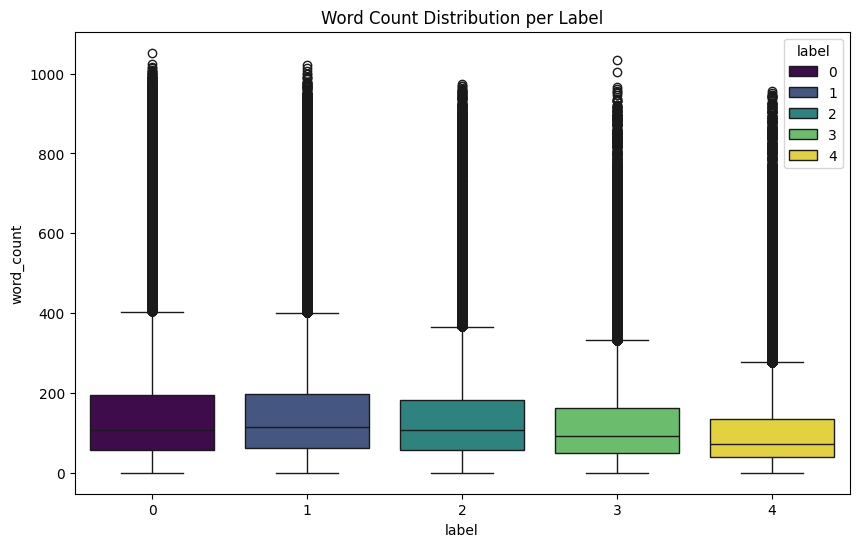

In [ ]:

# 3. Average Word Count per Label
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='word_count', data=df, hue='label', palette='viridis')
plt.title('Word Count Distribution per Label')

plt.show()


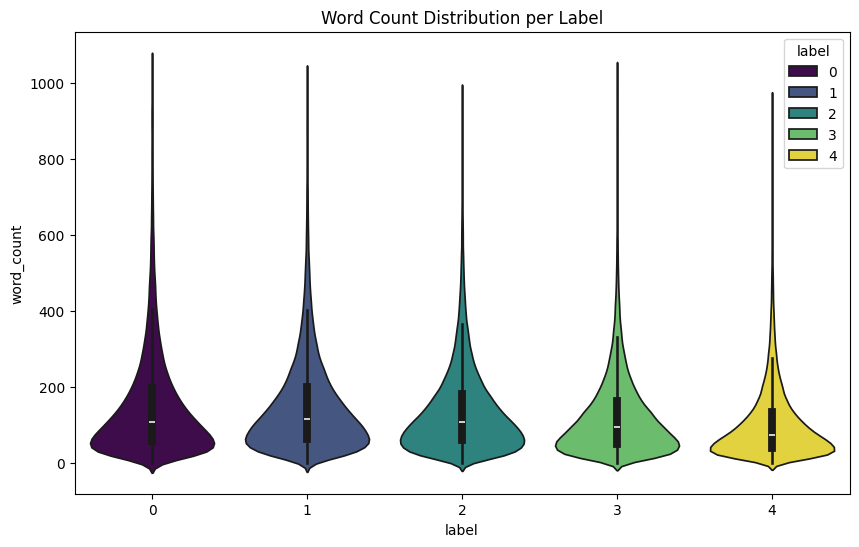

In [ ]:

plt.figure(figsize=(10, 6))
sns.violinplot(x='label', y='word_count', data=df, hue='label', palette='viridis')
plt.title('Word Count Distribution per Label')

plt.show()


## Fase 3: Análisis de Contenido y NLP
### 3.1 Identificación de Palabras Clave
Filtramos 'stop-words' para extraer los términos con mayor carga semántica en las reseñas positivas y negativas.

In [ ]:


# Download the stopwords dataset
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Update the function to exclude stopwords
def get_top_n_words_filtered(corpus, n=None, n_gram=1):
    words = []
    for text in corpus:
        text = text.lower()
        tokens = re.findall(r'\b\w+\b', text)
        # Filter out stopwords and very short tokens
        tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

        if n_gram > 1:
            tokens = [' '.join(tokens[i:i+n_gram]) for i in range(len(tokens)-n_gram+1)]
        words.extend(tokens)

    return Counter(words).most_common(n)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


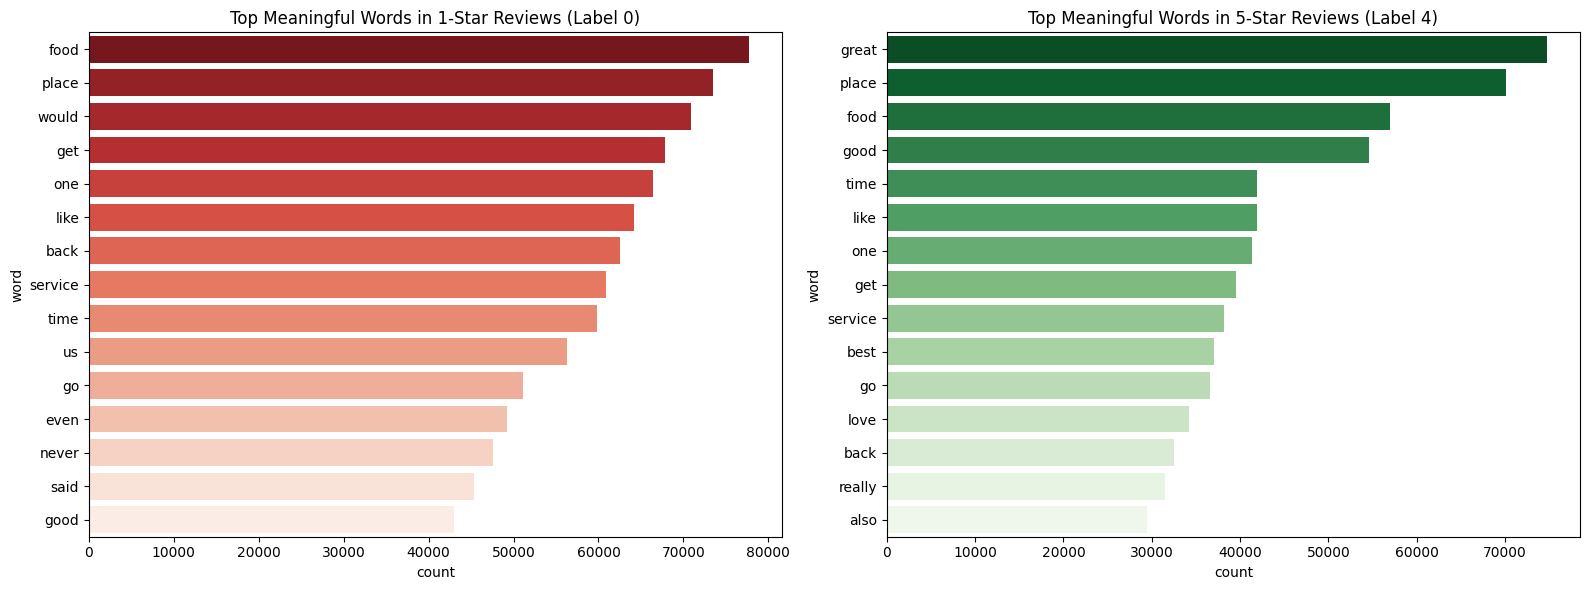

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get top words for both classes
top_0 = get_top_n_words_filtered(df[df['label']==0]['text'], n=15)
top_4 = get_top_n_words_filtered(df[df['label']==4]['text'], n=15)

# Convert to DataFrames for easier plotting
df_0 = pd.DataFrame(top_0, columns=['word', 'count'])
df_4 = pd.DataFrame(top_4, columns=['word', 'count'])

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='count', y='word', data=df_0, ax=ax1, hue='word', palette='Reds_r', legend=False)
ax1.set_title('Top Meaningful Words in 1-Star Reviews (Label 0)')

sns.barplot(x='count', y='word', data=df_4, ax=ax2, hue='word', palette='Greens_r', legend=False)
ax2.set_title('Top Meaningful Words in 5-Star Reviews (Label 4)')

plt.tight_layout()
plt.show()

## Fase 4: Definición de Variable Objetivo y Estadísticas de Rúbrica
### 4.1 Creación de Sentimiento Binario
Transformamos las categorías originales en una variable binaria (Negativo/Positivo) y extraemos las estadísticas finales según los estándares de la rúbrica (Mediana e IQR).

In [ ]:
# Map labels to binary sentiment
# Original Label: 0(1*), 1(2*), 2(3*) -> 0: Negative
# Original Label: 3(4*), 4(5*) -> 1: Positive
def map_sentiment(label):
    if label <= 2:
        return 0
    else:
        return 1

df['sentiment'] = df['label'].apply(map_sentiment)

print('-' * 60)
print("Sentiment distribution:")
print(df['sentiment'].value_counts())
print('-' * 60)


------------------------------------------------------------
Sentiment distribution:
sentiment
0    390000
1    260000
Name: count, dtype: int64
------------------------------------------------------------


In [ ]:
display(df[['label', 'sentiment', 'text']].head())

,label,sentiment,text
0,4,1,dr. goldberg offers everything i look for in a...
1,1,0,"Unfortunately, the frustration of being Dr. Go..."
2,3,1,Been going to Dr. Goldberg for over 10 years. ...
3,3,1,Got a letter in the mail last week that said D...
4,0,0,I don't know what Dr. Goldberg was like before...


In [ ]:
import numpy as np

# Calculate statistics for the asymmetric variable: word_count
median_words = df['word_count'].median()
q1 = df['word_count'].quantile(0.25)
q3 = df['word_count'].quantile(0.75)
iqr = q3 - q1
min_w = df['word_count'].min()
max_w = df['word_count'].max()

print('-' * 60)
print(f"Estadísticas de word_count (Variable Asimétrica)")
print(f"Mediana: {median_words}")
print(f"Rango Intercuartil (IQR): {iqr} (Q1: {q1}, Q3: {q3})")
print(f"Rango Total: {min_w} a {max_w}")

# Frequency and Percentage for Categorical variable: sentiment
sentiment_counts = df['sentiment'].value_counts()
sentiment_pct = df['sentiment'].value_counts(normalize=True) * 100

print('-' * 60)
print(f"Estadísticas de sentiment (Variable Categórica)")
for idx in sentiment_counts.index:
    label = 'Positivo' if idx == 1 else 'Negativo'
    print(f"{label}: {sentiment_counts[idx]} casos ({sentiment_pct[idx]:.1f}%)")
print('-' * 60)


------------------------------------------------------------
Estadísticas de word_count (Variable Asimétrica)
Mediana: 99.0
Rango Intercuartil (IQR): 123.0 (Q1: 52.0, Q3: 175.0)
Rango Total: 1 a 1052
------------------------------------------------------------
Estadísticas de sentiment (Variable Categórica)
Negativo: 390000 casos (60.0%)
Positivo: 260000 casos (40.0%)
------------------------------------------------------------


In [ ]:
display(df['word_count'].describe())

,word_count
count,650000.000000
mean,134.098089
std,121.396115
min,1.000000
25%,52.000000
50%,99.000000
75%,175.000000
max,1052.000000


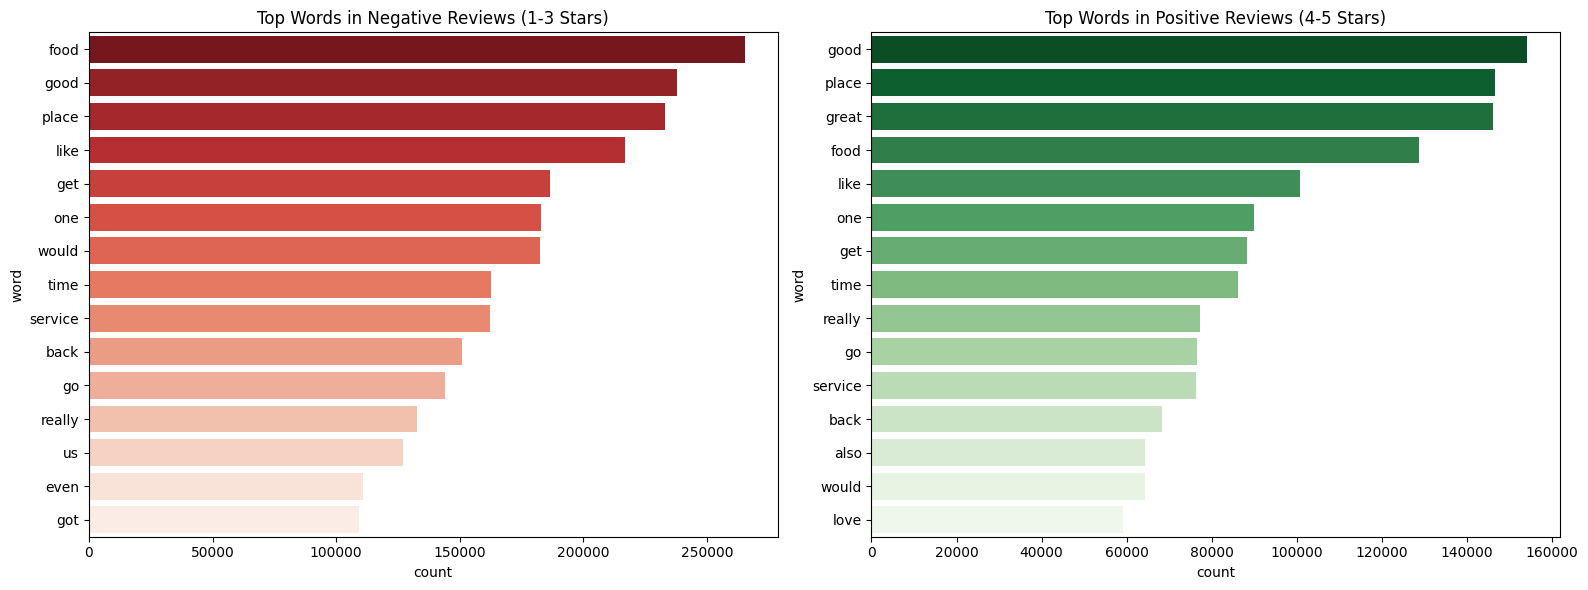

In [ ]:
# Analyze top 15 words for the new sentiment categories
# Using a subset for speed, but much larger than before
top_neg = get_top_n_words_filtered(df[df['sentiment']==0]['text'], n=15)
top_pos = get_top_n_words_filtered(df[df['sentiment']==1]['text'], n=15)

df_neg = pd.DataFrame(top_neg, columns=['word', 'count'])
df_pos = pd.DataFrame(top_pos, columns=['word', 'count'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='count', y='word', data=df_neg, ax=ax1, hue='word', palette='Reds_r', legend=False)
ax1.set_title('Top Words in Negative Reviews (1-3 Stars)')

sns.barplot(x='count', y='word', data=df_pos, ax=ax2, hue='word', palette='Greens_r', legend=False)
ax2.set_title('Top Words in Positive Reviews (4-5 Stars)')

plt.tight_layout()
plt.show()

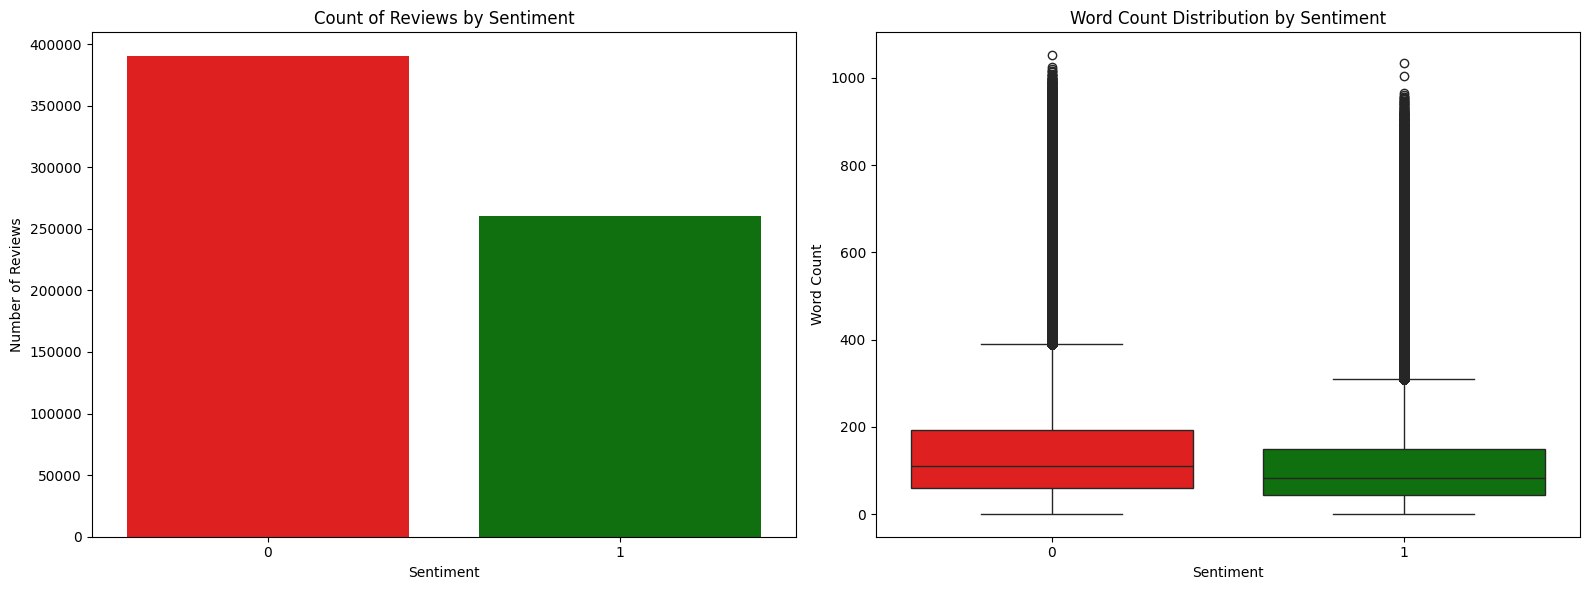

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar plot of Sentiment Distribution
sns.countplot(x='sentiment', data=df, ax=ax1, hue='sentiment', palette=['r','g'], legend=False)
ax1.set_title('Count of Reviews by Sentiment')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Number of Reviews')

# 2. Box plot of Word Count by Sentiment
sns.boxplot(x='sentiment', y='word_count', data=df, ax=ax2, hue='sentiment', palette=['r','g'], legend=False)
ax2.set_title('Word Count Distribution by Sentiment')
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Word Count')
#ax2.set_ylim(0, 500) # Limit y-axis to see the boxes clearly

plt.tight_layout()
plt.show()

---